In [124]:
import networkx as nx
import random
import numpy as np
import time
import subprocess
import pandas as pd
import os
import matplotlib.pyplot as plt
import shutil
import csv


In [125]:
VERBOSE = False

# Graph mutations functions

In [126]:
def delete_random_node(G):

    if len(G.nodes()) > 0:
        # Select a random node
        random_node = random.choice(list(G.nodes))
        # Remove the random node
        G.remove_node(random_node)

        if VERBOSE:
            print("Removed node:", random_node)
        else:
            return "Removed node: " + random_node

In [127]:
def add_random_node(G):
    # Creates a random node name
    name_node = str(len(G.nodes()) + 1)
    # Checks if node name already exists in graph
    while name_node in G.nodes():
        name_node = str(int(name_node) + 1)
    
    type_n = random.sample(list(DICT_SHAPE_TYPE.keys()), 1)[0]
    
    node_source = random.sample(list(G.nodes), 1)[0]
    type_e = random.sample(list(DICT_EDGE_TYPE.keys()), 1)[0]
    G.add_node(name_node, shape=type_n)
    G.add_edge(node_source, name_node, action=type_e)
    if VERBOSE:
        print("Created a new node: ", name_node, "connected with", node_source)
    else:
        return "Created a new node: " + name_node + " connected with " + node_source


In [128]:
def add_random_edge(G):
    # Select two random nodes
    random_edge = random.sample(list(G.nodes), 2)

    # Checks if edge already exists
    while G.has_edge(random_edge[0], random_edge[1]):
        random_edge = random.sample(list(G.nodes), 2)
    
    # Determines the random action
    # TODO use only allowed types edges --> by now it does not matter as edge type is not considered
    type_e = random.sample(list(DICT_EDGE_TYPE.keys()), 1)[0]

    # Create the new edge
    G.add_edge(random_edge[0], random_edge[1], action=type_e)
    
    if VERBOSE:
        print("Created a new edge: (", random_edge[0], ",", random_edge[1], ")")
    else:
        return "Created a new edge: (" + random_edge[0] + "," + random_edge[1] + ")"


In [129]:
def delete_random_edge(G):
    if len(G.edges()) > 0:
     # Select a random edge
        random_edge = random.choice(list(G.edges))
        # Remove the random edge
        G.remove_edge(random_edge[0], random_edge[1])
        
        if VERBOSE:
            print("Removed edge: (", random_edge[0], random_edge[1], ")")
        else:
            return "Removed edge: ("+ random_edge[0] +', ' + random_edge[1] + ")"

In [130]:
def change_direction_edge(G):
    if len(G.edges()) > 0:
        # Select a random edge
        random_edge = random.choice(list(G.edges))
        # Remove the random edge
        act = nx.get_edge_attributes(G, "action")
        G.remove_edge(random_edge[0], random_edge[1])
        G.add_edge(random_edge[1], random_edge[0], action=act[(random_edge[0], random_edge[1])])
        
        if VERBOSE:
            print("Previous edge: (", random_edge[0], random_edge[1], ")")
            print("New edge: (", random_edge[1], ",", random_edge[0], ")")
        else:
            return "Changed direction of edge. Previous edge: (" + random_edge[0] + ', ' + random_edge[1] + ") --> New edge: (" + random_edge[1] + ", " + random_edge[0] + ")"

In [131]:
def change_edge(G):
    edge_to_remove = random.choice(list(G.edges))

    G.remove_edge(*edge_to_remove)

    nodes = list(G.nodes)
    new_edge = (random.choice(nodes), random.choice(nodes))

    while new_edge[0] == new_edge[1] or G.has_edge(*new_edge):
        new_edge = (random.choice(nodes), random.choice(nodes))

    type_e = random.sample(list(DICT_EDGE_TYPE.keys()), 1)[0]

    G.add_edge(*new_edge, action=type_e)

    if VERBOSE:
        print("Previous edge: (", str(edge_to_remove), ")")
        print("New edge: (", str(new_edge), ")")
    else:
        return "Changed edge. Previous edge: (" + str(edge_to_remove) + ") --> New edge: (" + str(new_edge) + ")"

In [132]:
def rename_node(G):
    # Select a random node
    random_node = random.choice(list(G.nodes))
    # Creates a random node name
    name_node = str(len(G.nodes()) + 1)
    # Checks if node name already exists in graph
    while name_node in G.nodes():
        name_node = str(int(name_node) + 1)
    nx.relabel_nodes(G, {random_node: name_node}, copy=False)
    G.nodes[name_node]["label"] = name_node
    if VERBOSE:
        print("Previous node: ", random_node)
        print("New node name: ", name_node)
    else:
        return "Changed label of node. Previous node name: " + random_node + " --> New node name: " + name_node

In [133]:
def mute_graph(G, mutations_allowed, num_mutations=1):
    log_mutations = []
    for i in range(num_mutations):
        if VERBOSE:
            print(str(i) + "-th mutation")
        random.seed(time.time())
        random_mutation = random.choice(mutations_allowed)
        str_mut = random_mutation(G)
        log_mutations.append(str_mut)

    """nodo_objetivo = list(G.nodes)[0]
    print(nodo_objetivo)
    # Seleccionamos la componente conexa a partir del nodo inicial    
    componente_fuertemente_conexa = next(cc for cc in nx.weakly_connected_components(G) if nodo_objetivo in cc)
    # Crear un subgrafo con la componente conexa
    subgrafo = G.subgraph(componente_fuertemente_conexa)
    subgrafo_alcanzable = nx.dfs_tree(G, source=nodo_objetivo)
    # Copiar atributos de nodos
    for nodo in subgrafo_alcanzable.nodes:
        if nodo in G.nodes:
            subgrafo_alcanzable.nodes[nodo].update(G.nodes[nodo])

    # Copiar atributos de aristas
    for u, v in subgrafo_alcanzable.edges:
        if G.has_edge(u, v):
            subgrafo_alcanzable.edges[u, v].update(G.edges[u, v])
    

    componente_mas_grande = max(nx.weakly_connected_components(G), key=len)

    # Crear el subgrafo correspondiente
    subgrafo_componente_grande = G.subgraph(componente_mas_grande).copy()"""


    # Inicializar variables para almacenar el DFS Tree más grande
    """max_tree_size = 0
    largest_dfs_tree = None

    # Iterar sobre todos los nodos como posibles raíces
    for nodo in G.nodes:
        # Generar el DFS Tree desde el nodo actual
        dfs_tree = nx.dfs_tree(G, source=nodo)
        
        # Comparar el tamaño del árbol actual con el máximo registrado
        if len(dfs_tree.nodes) > max_tree_size:
            max_tree_size = len(dfs_tree.nodes)
            largest_dfs_tree = dfs_tree.copy()  #


    # Copiar atributos de nodos
    for nodo in largest_dfs_tree.nodes:
        if nodo in G.nodes:
            largest_dfs_tree.nodes[nodo].update(G.nodes[nodo])

    # Copiar atributos de aristas
    for u, v in largest_dfs_tree.edges:
        if G.has_edge(u, v):
            largest_dfs_tree.edges[u, v].update(G.edges[u, v])"""


    # return largest_dfs_tree
    return G, log_mutations

# METRICS

In [134]:
def intersection_lists(or_lst2, or_lst1):
    lst1 = or_lst1.copy()
    lst2 = or_lst2.copy()
    comm_list = []
    for i in or_lst1:
        if i in lst2:
            comm_list.append(i)
            lst1.remove(i)
            lst2.remove(i)
    return comm_list

In [135]:
def calc_precision(G_base, G_candidate):
    """
    Calculate precision for node sets of two graphs.
    
    Parameters:
    G_base: Ground truth graph (networkx graph)
    G_candidate: Candidate graph generated by PIDS (networkx graph)
    
    Returns:
    Precision value (float)
    """
    
    set_G_base = [(node_id, G_base.nodes[node_id]) for node_id in G_base.nodes()]
    set_G_candidate = [(node_id, G_candidate.nodes[node_id]) for node_id in G_candidate.nodes()]
    
    common_nodes = intersection_lists(list(set_G_base), list(set_G_candidate))
    count_common_nodes = len(common_nodes)

    return count_common_nodes/len(G_candidate) if len(G_base) > 0 else 0.0

In [136]:
def calc_recall(G_base, G_candidate):
    """
    Calculate recall for node sets of two graphs.
    
    Parameters:
    G_base: Ground truth graph (networkx graph)
    G_candidate: Candidate graph generated by PIDS (networkx graph)
    
    Returns:
    Recall value (float)
    """
    set_G_base = [(node_id, G_base.nodes[node_id]) for node_id in G_base.nodes()]
    set_G_candidate = [(node_id, G_candidate.nodes[node_id]) for node_id in G_candidate.nodes()]

    common_nodes = intersection_lists(list(set_G_base), list(set_G_candidate))
    count_common_nodes = len(common_nodes)
    
    return count_common_nodes / len(G_base) if len(G_base) > 0 else 0.0

In [137]:

def calc_f1_score(G_base, G_candidate):
    """
    Calculate the F1-score given precision and recall.
    
    Parameters:
    precision: Precision value (float)
    recall: Recall value (float)
    
    Returns:
    F1-score (float)
    """
    precision = calc_precision(G_base, G_candidate)
    recall = calc_recall(G_base, G_candidate)
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

In [156]:
G = nx.read_gexf("graphs/grafo_kairos.gexf")
G_base = G.copy()

In [139]:
NAME_DS = "CUSTOM2"
path_graphs = "SDTED/Data/" + NAME_DS + "/"

In [140]:
IDS_AS_TYPES= True
DICT_SHAPE_TYPE = {
    "ellipse": "file",
    "rectangle": "process",
    "diamond": "connection"
}

DICT_EDGE_TYPE = {
    "create": 0,
    "read": 1,
    "open": 2,
    "connect": 3,
    "send": 4, 
    "receive": 5,
    "write": 6,
    "execute": 7
}
    
DICT_NODE_TYPE = {
    "file": 0,
    "process": 1,
    "connection": 2
}


In [141]:
# list_graphs must be an array of all the graphs that must be compared for getting distance matrixes
def write_SDTED_graphs_old(arr_graphs):
    # First of all, I have to perform a re-assignment of node ids, because with this methodology each node id is unique, even if they are from different graphs
    arr_nodes = []
    arr_graphs_aux = []
    # 1 because it has to start with 1 to correspond to the 1st line
    i = 1
    mapping = {}
    type_dict = {} 
    # We use it to store the history of all ids correspondences
    mapping_inverse = {}  

    for index, graph in enumerate(arr_graphs):

        for node in graph.nodes():
            mapping[node] = i
            mapping_inverse[i] = node
            d = nx.get_node_attributes(graph, "shape")
            type_dict[i] = DICT_SHAPE_TYPE[d[node]]
            i = i + 1
        H = nx.relabel_nodes(graph, mapping)
        if IDS_AS_TYPES:
            dict_graph = {}
            for node in H.nodes():
                dict_graph[node] = node
            nx.set_node_attributes(H, dict_graph, name="type")
        arr_graphs_aux.append(H)

    arr_graphs = arr_graphs_aux   

    open(path_graphs + NAME_DS + "_graph_indicator.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_graph_indicator.txt", "a") as f:
            for node in graph.nodes():
                # Index must start with 1
                f.write(str(index + 1) + '\n')
    
    open(path_graphs + NAME_DS +"_A.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_A.txt", "a") as f:
            for edge in graph.edges():
                # The i-th node corresponds to the i-th row (starting with 1).
                f.write(str(edge[0]) + ', ' + str(edge[1] ) + '\n')

    open(path_graphs + NAME_DS + "_edge_labels.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_edge_labels.txt", "a") as f:
            actions = nx.get_edge_attributes(graph, 'action')
            for edge in graph.edges():
                f.write(str(DICT_EDGE_TYPE[actions[(edge[0], edge[1])]]) + '\n')


    open(path_graphs + NAME_DS +"_node_labels.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_node_labels.txt", "a") as f:
            for node in graph.nodes():
                if IDS_AS_TYPES:
                    types = nx.get_node_attributes(graph, "type")
                    f.write(str(types[node]) + '\n')
                else:
                    shapes = nx.get_node_attributes(graph, "shape")
                    f.write(str(DICT_NODE_TYPE[DICT_SHAPE_TYPE[shapes[node]]]) + '\n')


    # New file type that stores the types of each id (to calculate the initial cost matrix)
    # The file consists of a dictionary separated with commas.  First col = id, second col = type
    if IDS_AS_TYPES:
        path_file = path_graphs + NAME_DS + "_node_types.txt"
        with open(path_file, "w") as f:
            for key_dict in type_dict.keys():
                f.write(str(key_dict) + ',' + str(DICT_NODE_TYPE[type_dict[key_dict]]) + '\n')
        
        path_file2 = path_graphs + NAME_DS + "_node_ids.txt"
        with open(path_file2, "w") as f:
            for key_dict in mapping_inverse.keys():
                f.write(str(key_dict) + ',' + str(mapping_inverse[key_dict]) + '\n')
    

    with open(path_graphs + NAME_DS + "_graph_labels.txt", "w") as f:
        for index, graph in enumerate(arr_graphs):
            f.write("1\n")

In [142]:
# list_graphs must be an array of all the graphs that must be compared for getting distance matrixes
def write_SDTED_graphs(arr_graphs):
    # First of all, I have to perform a re-assignment of node ids, because with this methodology each node id is unique, even if they are from different graphs
    arr_nodes = []
    arr_graphs_aux = []
    # 1 because it has to start with 1 to correspond to the 1st line
    i = 1
    j = 1
    mapping = {}
    mapping_A = []
    type_dict = {} 
    # We use it to store the history of all ids correspondences
    mapping_inverse = {}  

    for index, graph in enumerate(arr_graphs):

        for node in graph.nodes():
            if node not in mapping.keys():
                mapping[node] = i
                mapping_inverse[i] = node
                d = nx.get_node_attributes(graph, "shape")
                type_dict[i] = DICT_SHAPE_TYPE[d[node]]
                i = i + 1
        H = nx.relabel_nodes(graph, mapping)
        if IDS_AS_TYPES:
            dict_graph = {}
            mapping_A.append({})
            for node in H.nodes():
                dict_graph[node] = node
                mapping_A[index][node] = j
                j = j + 1

            nx.set_node_attributes(H, dict_graph, name="type")
        arr_graphs_aux.append(H)

    arr_graphs = arr_graphs_aux   

    open(path_graphs + NAME_DS + "_graph_indicator.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_graph_indicator.txt", "a") as f:
            for node in graph.nodes():
                # Index must start with 1
                f.write(str(index + 1) + '\n')
    
    open(path_graphs + NAME_DS +"_A.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_A.txt", "a") as f:
            for edge in graph.edges():
                # The i-th node corresponds to the i-th row (starting with 1).
                f.write(str(mapping_A[index][edge[0]]) + ', ' + str(mapping_A[index][edge[1]]) + '\n')

    open(path_graphs + NAME_DS + "_edge_labels.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_edge_labels.txt", "a") as f:
            actions = nx.get_edge_attributes(graph, 'action')
            for edge in graph.edges():
                f.write(str(DICT_EDGE_TYPE[actions[(edge[0], edge[1])]]) + '\n')


    open(path_graphs + NAME_DS +"_node_labels.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_node_labels.txt", "a") as f:
            for node in graph.nodes():
                if IDS_AS_TYPES:
                    types = nx.get_node_attributes(graph, "type")
                    f.write(str(types[node]) + '\n')
                else:
                    shapes = nx.get_node_attributes(graph, "shape")
                    f.write(str(DICT_NODE_TYPE[DICT_SHAPE_TYPE[shapes[node]]]) + '\n')


    # New file type that stores the types of each id (to calculate the initial cost matrix)
    # The file consists of a dictionary separated with commas.  First col = id, second col = type
    if IDS_AS_TYPES:
        path_file = path_graphs + NAME_DS + "_node_types.txt"
        with open(path_file, "w") as f:
            for key_dict in type_dict.keys():
                f.write(str(key_dict) + ',' + str(DICT_NODE_TYPE[type_dict[key_dict]]) + '\n')
        
        path_file2 = path_graphs + NAME_DS + "_node_ids.txt"
        with open(path_file2, "w") as f:
            for key_dict in mapping_inverse.keys():
                f.write(str(key_dict) + ',' + str(mapping_inverse[key_dict]) + '\n')
    

    with open(path_graphs + NAME_DS + "_graph_labels.txt", "w") as f:
        for index, graph in enumerate(arr_graphs):
            f.write("1\n")

In [143]:
def find_min(arr):
    minim = 1
    for arr_met in arr:
        for index, met in enumerate(arr_met):
            #if index == 3:
            #    met = [1 - min(x / met[-1], 1) for x in met][1:][:-1]
            minim_aux = min(met)
            if minim_aux < minim:
                minim = minim_aux
    return minim


In [166]:
arr_mutations = [delete_random_node, delete_random_edge, change_direction_edge, add_random_node, add_random_edge, change_edge]
NUM_MAX_MUTATIONS = 10
# Number of copies of the original graph
NUM_GRAPHS = 41

In [172]:
arr_mut_metrics = []

for num_mutations in range(NUM_MAX_MUTATIONS + 1)[1::1]:
    arr_g_candidate = []
    arr_precs = []
    arr_recalls = []
    arr_f1s = []

    arr_g_candidate.append(G_base)
    for graph in range(NUM_GRAPHS):
        G_candidate = G_base.copy()
        #print(len(G.nodes()), len(G.edges()))
        G_muted, log_mutations = mute_graph(G_candidate, arr_mutations, num_mutations)
        folder_path = "graphs/" + NAME_DS + '/' + str(num_mutations) + '/'
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)
        nx.write_gexf(G_muted, folder_path + 'G_' + str(graph + 1) + ".gexf")
        with open(folder_path + 'G_' + str(graph + 1) + ".log", 'w') as f:  # 'w' mode overwrites existing content
            for string in log_mutations:
                f.write(string + '\n') 
        #print(len(G.nodes()), len(G.edges()))
        arr_precs.append(calc_precision(G_base, G_muted))
        arr_recalls.append(calc_recall(G_base, G_muted))
        arr_f1s.append(calc_f1_score(G_base, G_muted))
        arr_g_candidate.append(G_muted)

    arr_g_candidate.append(nx.DiGraph())

    """# We add the empty graph for executing SDTED
    G_nodes = nx.DiGraph()
    for node in G_base.nodes():
        G_nodes.add_node(node, shape=nx.get_node_attributes(G_base, "shape")[node])
    list_nodes = list(G_nodes.nodes())
    for index, node in enumerate(list_nodes[:-1]):
        type_e = random.sample(list(DICT_EDGE_TYPE.keys()), 1)[0]
        G_nodes.add_edge(node, list_nodes[index + 1], action=type_e)"""

    write_SDTED_graphs(arr_g_candidate)

    res = subprocess.run(
        ["python3", "main.py", "Data/CUSTOM2", "--h", "4"],
        capture_output=True,
        text=True,
        cwd="SDTED/"
    )
    print(str(num_mutations) + ': ' + str(res))
    df = pd.read_csv("SDTED/Distance_Matrix.csv", nrows=1)
    shutil.copy2("SDTED/Distance_Matrix.csv", "graphs/" + NAME_DS + '/' + str(num_mutations) + '/' + 'distance_matrix_'+ str(NUM_GRAPHS) + '.csv')  

    arr_SDTED = df.values.tolist()[0][1:]  # [0] gets the first (and only) row
    arr_SDTED = [1 - min(x / arr_SDTED[-1], 1) for x in arr_SDTED][1:][:-1]
    arr_metrics = [arr_precs, arr_recalls, arr_f1s, arr_SDTED]
    
    num_filas = max(len(arr) for arr in arr_metrics)

    trasp_metrics = []
    for i in range(num_filas):
        fila = [arr[i] if i < len(arr) else "" for arr in arr_metrics]
        trasp_metrics.append(fila)

    with open("graphs/" + NAME_DS + '/' + str(num_mutations) + '/metrics_' + str(NUM_GRAPHS) + '.csv' , "w", newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Precision", "Recall", "F1-score", "SDTED"])
        for array in trasp_metrics:
            writer.writerow(array)

    arr_mut_metrics.append(arr_metrics)


1: CompletedProcess(args=['python3', 'main.py', 'Data/CUSTOM2', '--h', '4'], returncode=1, stdout='Distances Matrix\n        G_base     G_1     G_2     G_3  ...    G_39    G_40    G_41    G_42\nG_base     0.0   182.0    28.0    33.0  ...    51.0    65.0    46.0  1181.0\nG_1      182.0     0.0   194.0   209.0  ...   178.0   179.0   184.0  1193.0\nG_2       28.0   194.0     0.0    61.0  ...    76.0    87.0    74.0  1211.0\nG_3       33.0   209.0    61.0     0.0  ...    77.0    95.0    73.0  1148.0\nG_4      107.0   158.0   132.0   129.0  ...   136.0   147.0   108.0  1194.0\nG_5      228.0   259.0   246.0   210.0  ...   237.0   249.0   232.0  1149.0\nG_6       62.0   187.0    89.0    89.0  ...    54.0    75.0    73.0  1154.0\nG_7       39.0   176.0    67.0    55.0  ...    66.0    74.0    48.0  1178.0\nG_8       36.0   178.0    64.0    52.0  ...    63.0    66.0    49.0  1166.0\nG_9       20.0   184.0    28.0    53.0  ...    68.0    79.0    66.0  1201.0\nG_10      49.0   209.0    54.0    80

In [ ]:
H = G_base.copy()
"""F = G_base.copy()
F2 = G_base.copy()
H.remove_node('gtcache')
F.remove_node('/var/log/mail')
F2.remove_node('mail')
nx.write_gexf(H, "H.gexf")
nx.write_gexf(F, "F.gexf")
nx.write_gexf(F2, "F2.gexf")"""
F = nx.read_gexf("graphs/CUSTOM2/1/")
write_SDTED_graphs([G_base, H, F, F2, nx.DiGraph()])
for i in range(10):
    res = subprocess.run(
            ["python3", "main.py", "Data/CUSTOM2", "--h", str(i)],
            capture_output=True,
            text=True,
            cwd="SDTED/"
        )
    print(res)

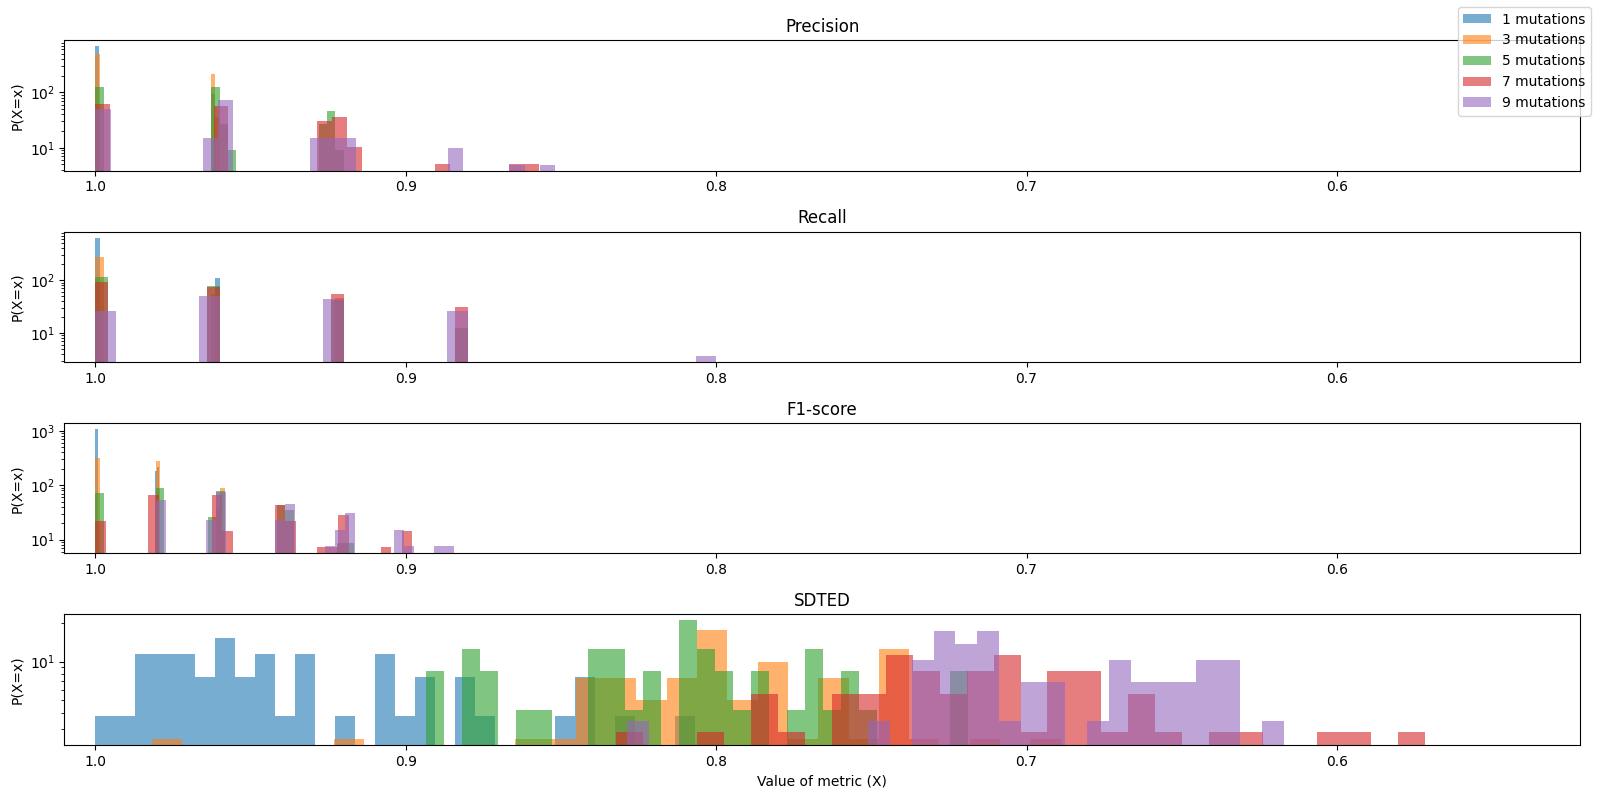

In [176]:
plt.style.use('default')
fig, axs = plt.subplots(4)
fig.set_size_inches(16, 8)

cdf_flag = False

#minim = min(min(arr_metric) for arr_metric in arr_mut_metrics)
minim = find_min(arr_mut_metrics)
axs[0].set_title("Precision")

axs[1].set_title("Recall")

axs[2].set_title("F1-score")

axs[3].set_title("SDTED")
axs[3].set_xlabel("Value of metric (X)")

if cdf_flag:
    for ax in axs:
        ax.set_ylabel("P(X>x)")
else:
    for ax in axs:
        ax.set_ylabel("P(X=x)")

for ax in axs:
    ax.invert_xaxis()
    ax.set_xlim(1.01, minim - 0.05)

if not cdf_flag:
    for ax in axs:
        ax.set_yscale('log')
        

alt_factor = 2
for num_mutations, metrics_num_mut in enumerate(arr_mut_metrics[::alt_factor]):
    for index, metric in enumerate(metrics_num_mut):
        #if index == 3:
        #    metric = [1 - min(x / metric[-1], 1) for x in metric][1:][:-1]
        if cdf_flag:
            met_sorted = np.sort(metric)[::-1]
            cdf = np.arange(1, len(met_sorted) + 1) / len(met_sorted)

            axs[index].plot(met_sorted, cdf, label=f"{num_mutations*alt_factor + 1} mutations" if index == 0 else "_nolegend_", alpha=0.8)
        else:
            axs[index].hist(metric, bins=30, density=True, alpha=0.6, label=f"{num_mutations*alt_factor + 1} mutations" if index == 0 else "_nolegend_")  # density=True normaliza el histograma
        
        # P(x=X)
        #values, counts = np.unique(metric, return_counts=True)
        #probabilities = counts / counts.sum()  # P(x=X) = frecuencia relativa
        # Graficar P(x=X)
        #axs[index].plot(values, probabilities, marker='.', linestyle='-', label=f"{num_mutations*alt_factor + 1} mutations" if index == 0 else "_nolegend_")



# Mostrar la leyenda solo una vez a nivel de figura
fig.legend(loc="upper right")
fig.tight_layout()
plt.show()
if cdf_flag:
    fig.savefig("plots/CDF_" + str(NUM_GRAPHS) + '_' + str(NUM_MAX_MUTATIONS) + '.png')
else:
    fig.savefig("plots/PDF_" + str(NUM_GRAPHS) + '_' + str(NUM_MAX_MUTATIONS) + '.png')


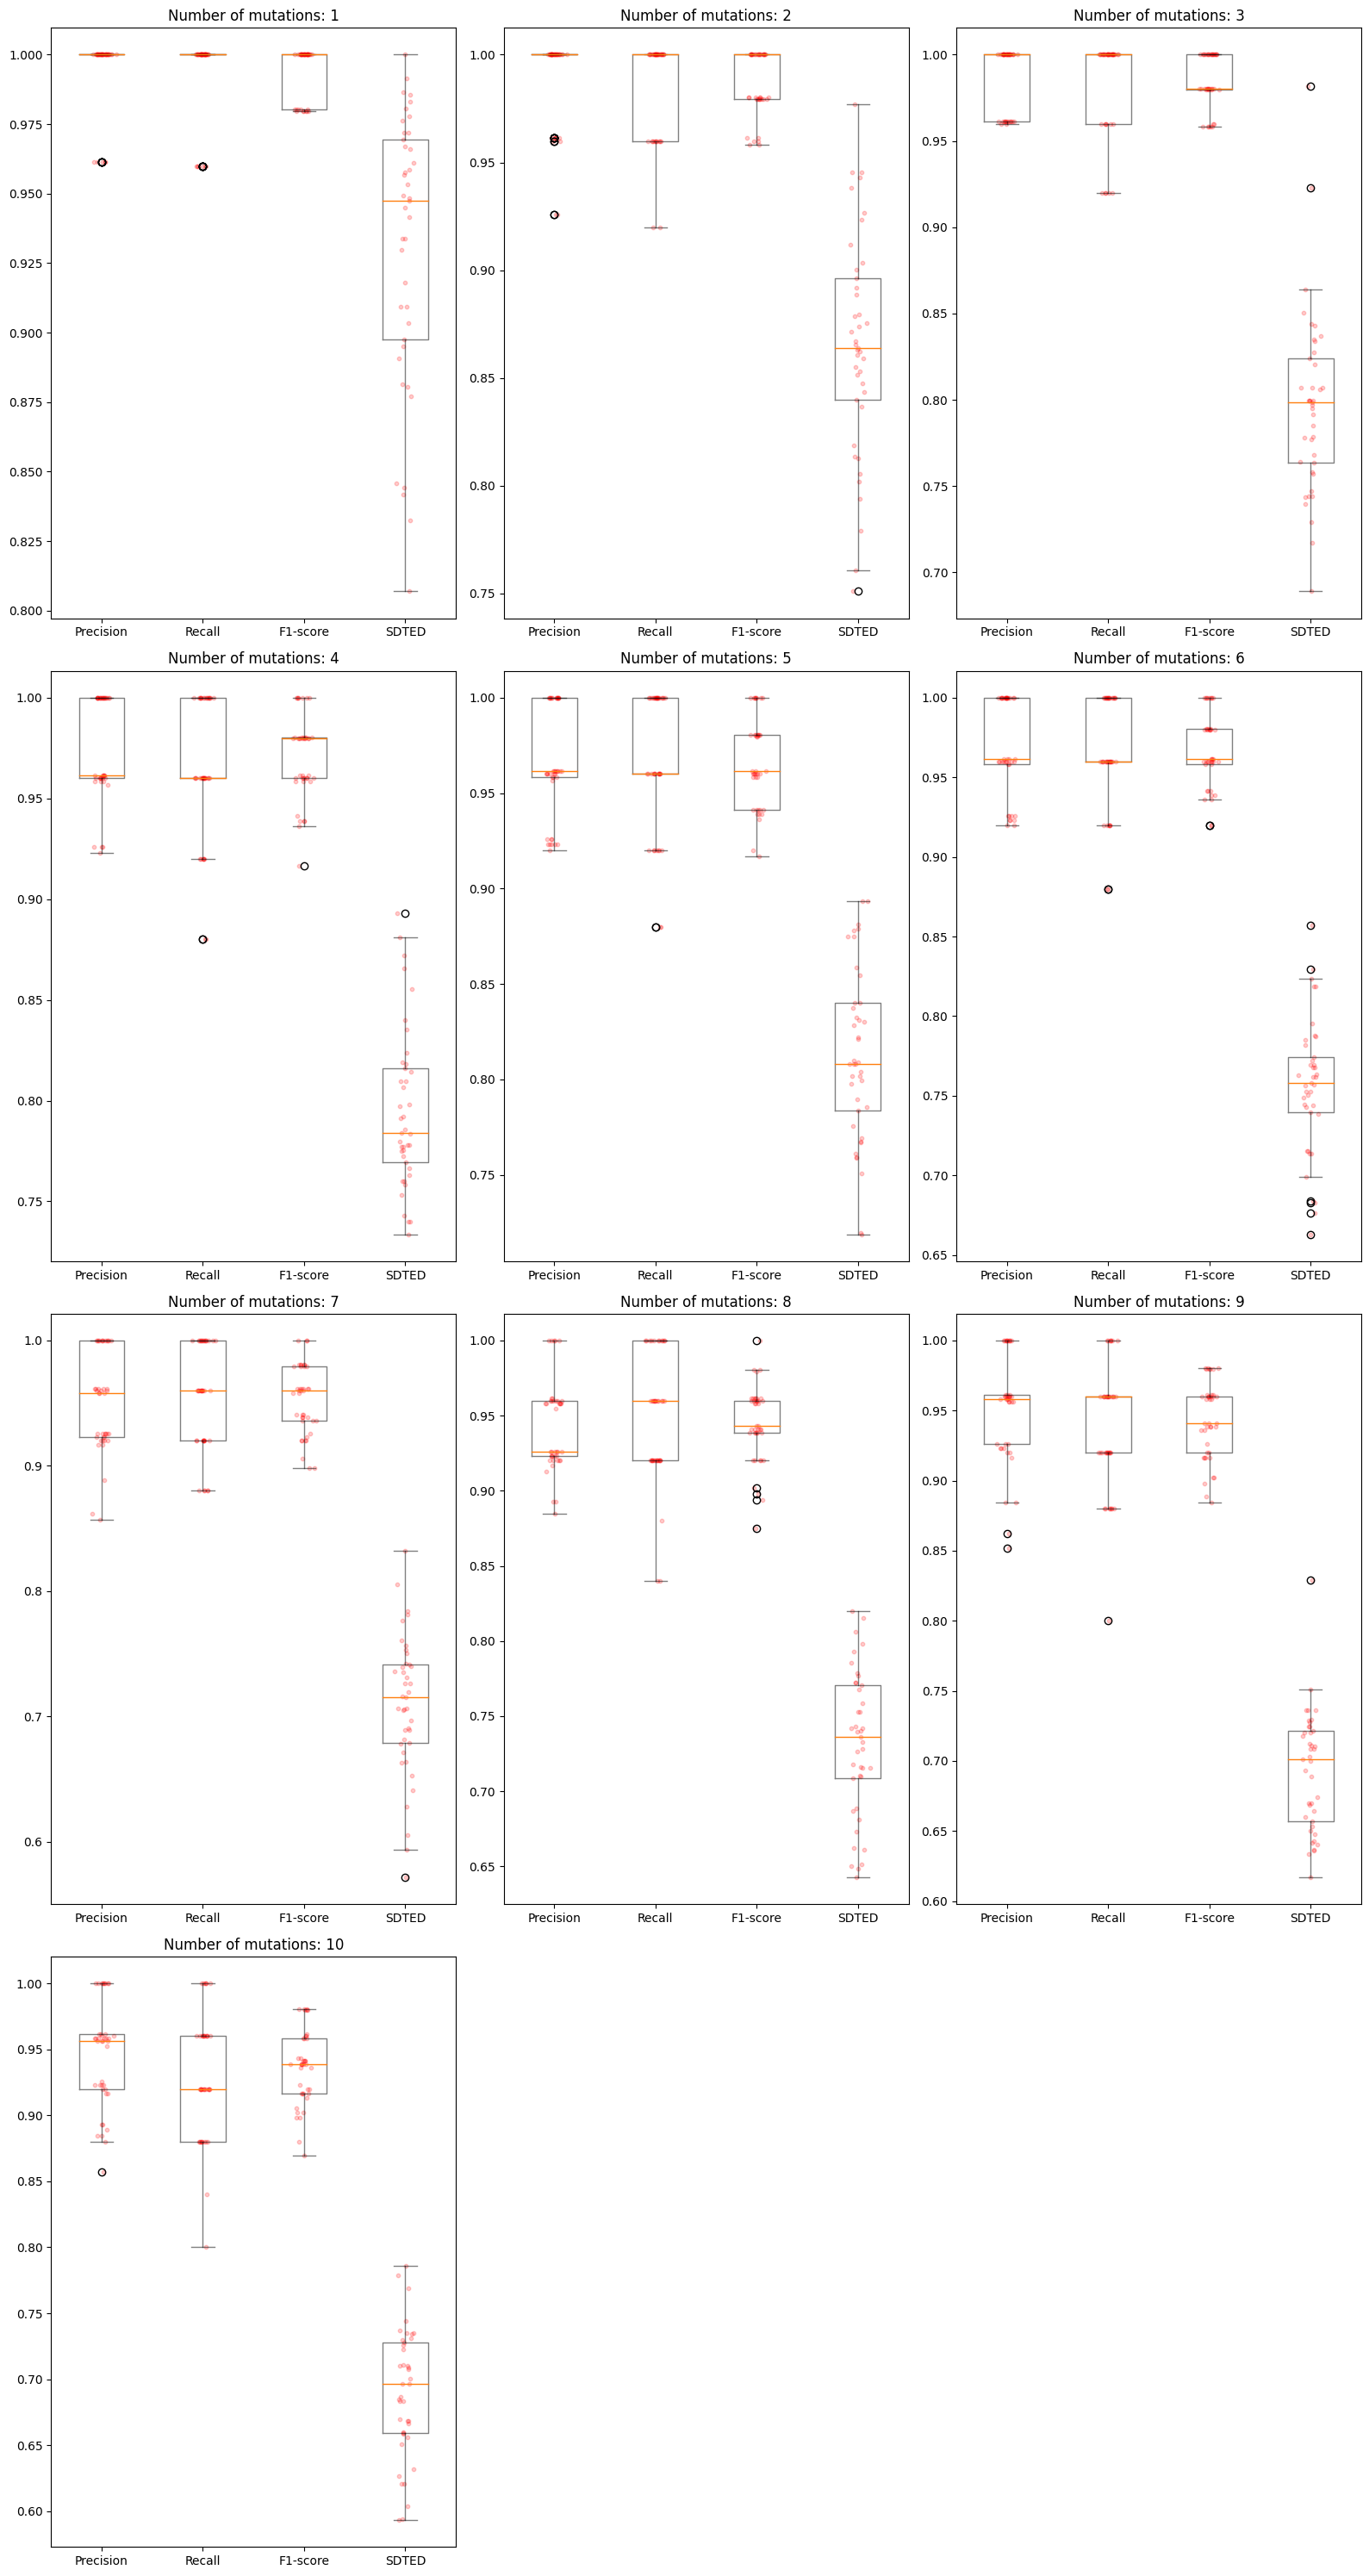

In [175]:

# Número de subplots
num_plots = len(arr_mut_metrics)  # En tu caso, 20
num_cols = 3  # 3 columnas por fila
num_rows = (num_plots + num_cols - 1) // num_cols  # Calcula las filas necesarias (redondeo hacia arriba)

plt.style.use('default')
fig, axs = plt.subplots(num_rows, num_cols, figsize=(16, 8))  # Tamaño ajustado
axs = axs.flatten()

fig.set_size_inches(16, 30)
for index, ax in enumerate(axs):
    if index < num_plots:
        arr = arr_mut_metrics[index].copy()
        
        box = ax.boxplot(arr, labels=["Precision", "Recall", "F1-score", "SDTED"])

        # Ajuste de transparencia
        for element in ['boxes', 'whiskers', 'caps']:
            for item in box[element]:
                item.set_alpha(0.5)
        for index_2, metric in enumerate(arr):
            # Puntos dispersos superpuestos
            x = np.random.normal(index_2 + 1, 0.04, size=len(metric))
            ax.scatter(x, metric, s=10, color='r', alpha=0.2)

        # Personaliza el título de cada subplot
        ax.set_title(f'Number of mutations: {index + 1}')
    else:
        ax.axis('off')  #
    #plt.set_yscale('log')
# Número de técnicas usadas por los gruposeach que \nhan usado al menos una técnica usada $N$ veces")
#plt.set_ylabel("num_groups_techniques($N$)")
#plt.set_xlabel("$N$")
plt.tight_layout()  # Ajusta el espaciado entre subplots
plt.show()
fig.savefig("plots/boxplots_" + str(NUM_GRAPHS) + '_' + str(NUM_MAX_MUTATIONS) + ".png")

In [120]:
len(G_base.nodes())

22

In [65]:
for a in range(10)[::2]:
    print(a)

0
2
4
6
8


# Flujo

# crear funcion de calculo de f1,prec,recall
# crear generaciones de n grafos con M mutaciones cada uno

# Añadir grafo vacío con tantos nodos como el inicial 
Alamcenar en una tabla las distancaias de cada n grafos (tabla nxn y coger la priomera col). 
Coger la max dist--> dist de ultima columna.
Normalizar y pasar a similitud

plot de metricas medias y de variacion

In [18]:
import os
arr_mutations = [delete_random_node, add_random_node, add_random_edge]

arr_g_candidate = []
arr_precs = []
arr_recalls = []
arr_f1s = []

arr_g_candidate.append(G_base)
for graph in range(NUM_GRAPHS):
    G_candidate = G_base.copy()
    # print(len(G.nodes()), len(G.edges()))
    G_muted, log_mutations = mute_graph(G_candidate, arr_mutations, NUM_MUTATIONS)
    nx.write_gexf(G_muted, "graphs/" + NAME_DS + '/G_' + str(graph + 1) + ".gexf")
    with open("graphs/" + NAME_DS + '/G_' + str(graph + 1) + ".log", 'w') as f:  # 'w' mode overwrites existing content
        for string in log_mutations:
            f.write(string + '\n') 
    # print(len(G_muted.nodes), len(G_muted.edges))
    # print(len(G.nodes()), len(G.edges()))
    arr_precs.append(calc_precision(G_base, G_muted))
    arr_recalls.append(calc_recall(G_base, G_muted))
    arr_f1s.append(calc_f1_score(G_base, G_muted))
    arr_g_candidate.append(G_muted)

arr_metrics = [arr_precs, arr_recalls, arr_f1s]
# We add the empty graph

G_nodes = nx.DiGraph()
for node in G_base.nodes():
    G_nodes.add_node(node, shape=nx.get_node_attributes(G_base, "shape")[node])
list_nodes = list(G_nodes.nodes())
for index, node in enumerate(list_nodes[:-1]):

    type_e = random.sample(list(DICT_EDGE_TYPE.keys()), 1)[0]
    G_nodes.add_edge(node, list_nodes[index + 1], action=type_e)


# Opción de añadir tantas aristas aleatorias como hay en G_base
"""for edge in G_base.edges():
    random_edge = random.sample(list(G_nodes.nodes), 2)
    type_e = random.sample(list(DICT_EDGE_TYPE.keys()), 1)[0]
    # Create the new edge
    G_nodes.add_edge(random_edge[0], random_edge[1], action=type_e)"""

# Opcióm grafo vacío
G_nodes = nx.DiGraph()
arr_g_candidate.append(G_nodes)

#G_nodes = nx.DiGraph()
#arr_g_candidate.pop()
#arr_g_candidate.append(G_nodes)
write_SDTED_graphs(arr_g_candidate)